In [44]:
import os
import tarfile
import urllib.request
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
## Load the data

DOWNLOAD_ROOT =  "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH  =  os.path.join("datasets", "housing")
HOUSING_URL   =  DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    
    os.makedirs(housing_path, exist_ok=True)
    tgz_path    = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [16]:
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [17]:
df = load_housing_data()
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


##### Eyeballing the data to understand the data

In [18]:
'''Its method is a quick way to:Understand the structure of your DataFrame (number of rows and columns).
Check the data types of each column.
Identify missing values in each column.
Estimate memory usage of the DataFrame.
'''

df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [19]:
# method in pandas provides a summary of statistical information about the numerical columns in a DataFrame.
# This method is highly useful for understanding the distribution and central tendencies of your data

df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [20]:
'''
Cardinality in the context of data analysis and databases refers to the uniqueness of data values within a column or attribute. 
It describes how many distinct values are present in a column and is useful for understanding the diversity or variability of data
'''

df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

##### Data Cleaning 


1. Handling Missing Nos
2. Handling Outliers
3. Feature Transformation

**1.Handling Missing Nos**

In [6]:
# How to check for missing nos
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

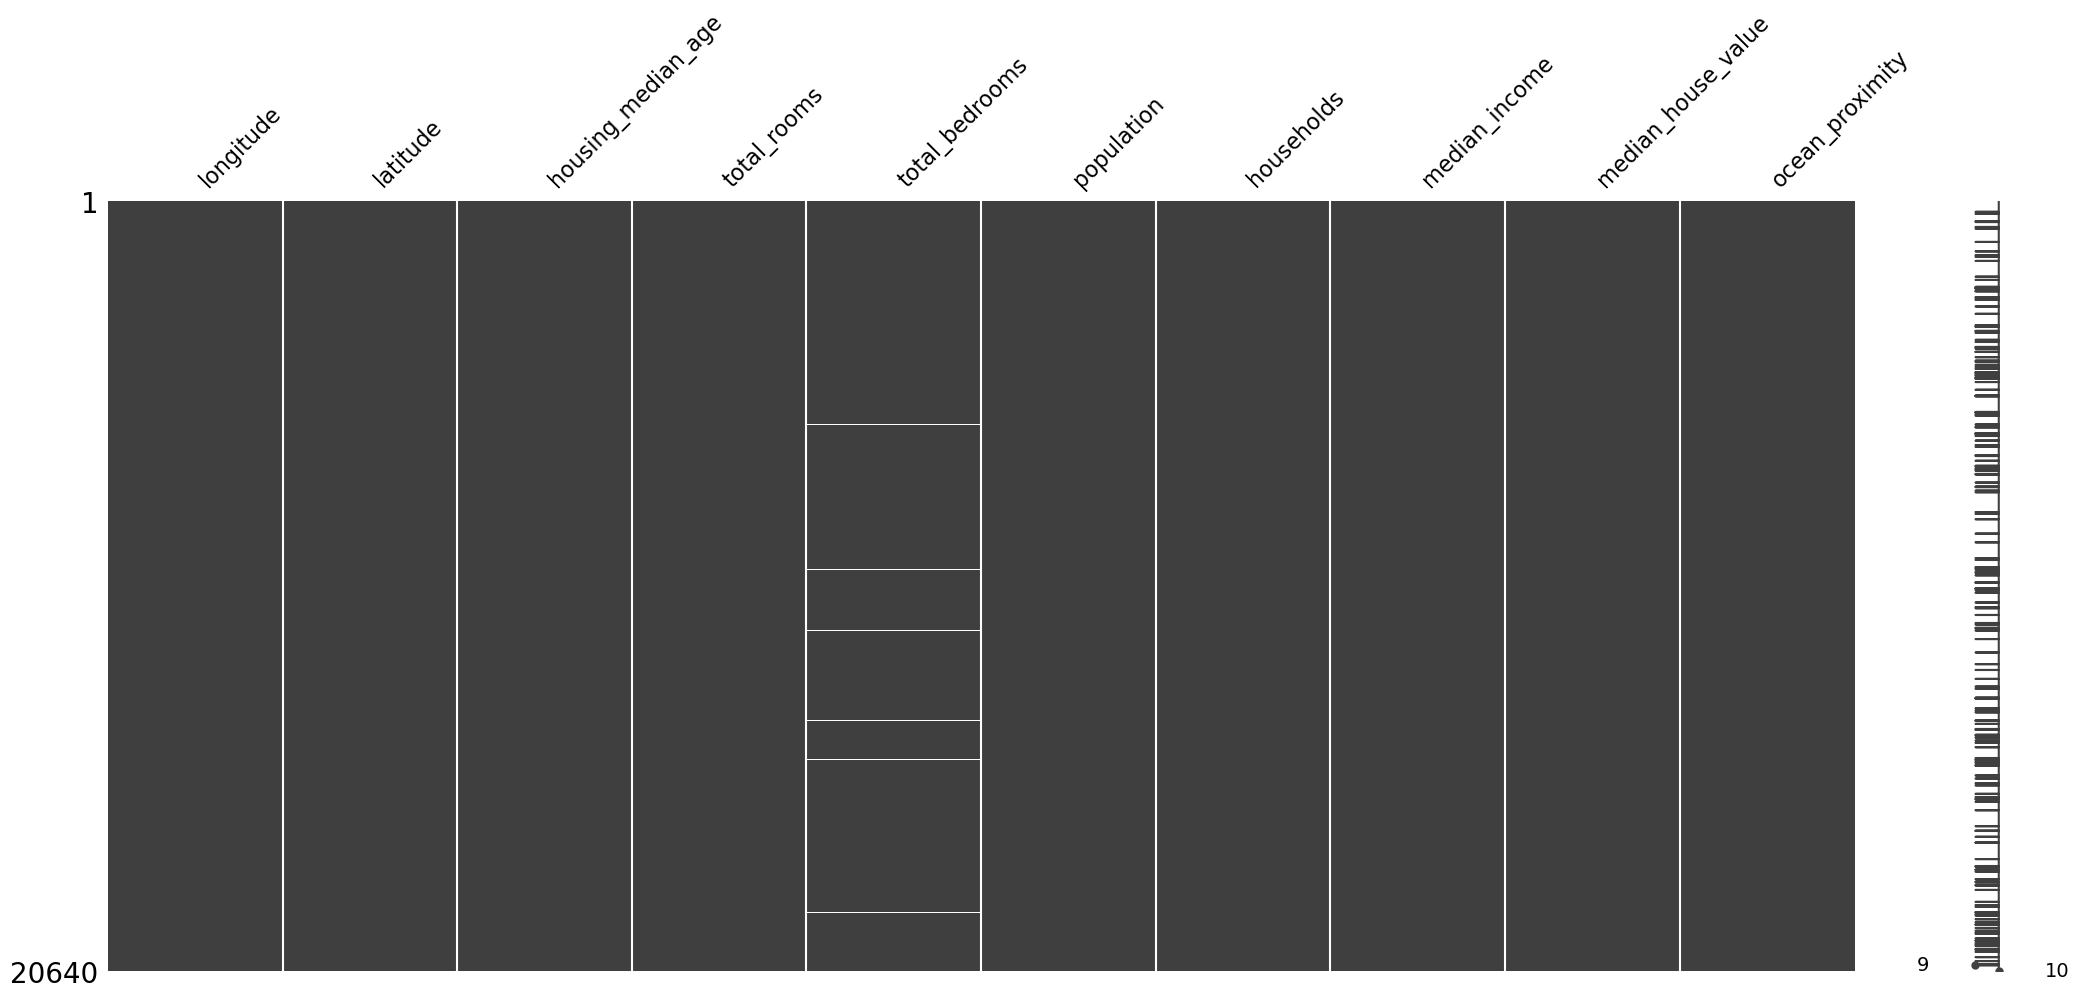

In [12]:
# We can also visualize our missing Nos using libraries like missingno

# pip install missingno
import missingno as mn

mn.matrix(df);

**1. Treating Missing Nos**

Understand the Nature of Missing Data is important in treating them

Determine why the data is missing:
1. Missing Completely at Random (MCAR): The missingness is random and does not depend on other data.
2. Missing at Random (MAR)             : The missingness is related to other observed data but not the missing data itself.
3. Missing Not at Random (MNAR)         : The missingness is related to the missing data itself.


----
----

**Methods of Hadling Missing Values**

1. Remove the missing values
2. Impoute missing values
    - Mean/Median/Mode Imputation
    - Forward/Backward Fill    Use the last known value (forward fill) or the next known value common in time-series data
    - Custom Imputation


In [22]:
# Drop Missing Values

df_cleaned    = df.dropna()
nrows_dropped = df.shape[0] - df_cleaned.shape[0]

print(df.shape)
print(df_cleaned.shape)
print(nrows_dropped)

(20640, 10)
(20433, 10)
207


In [24]:
# Use Imputation

# Mean Imputation
# df['total_bedrooms_imput_mean'] = df['total_bedrooms'].fillna(df['column'].mean())

# # Median Imputation
# df['total_bedrooms_impute_mode'] = df['total_bedrooms'].fillna(df['column'].median())


df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

**2.Handling Outliers**

<Axes: >

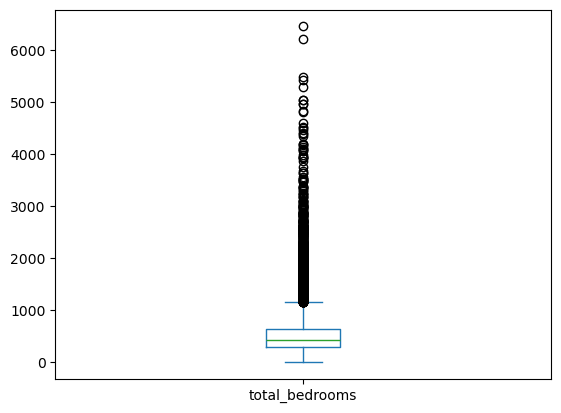

In [39]:
df['total_bedrooms'].plot(kind='box')

Outliers in housing_median_age:
Series([], Name: housing_median_age, dtype: float64)


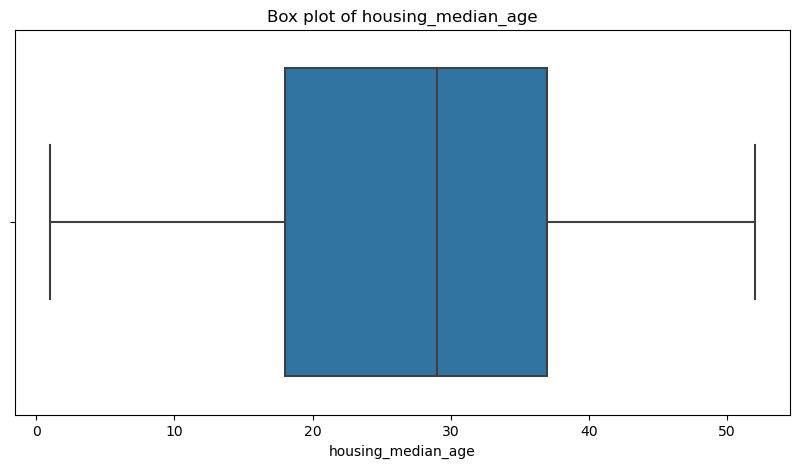

Outliers in total_rooms:
1         7099.0
101       5806.0
104       5871.0
185       5963.0
283      12842.0
          ...   
20543     6861.0
20544     8800.0
20563    12139.0
20567     6809.0
20629    10035.0
Name: total_rooms, Length: 1287, dtype: float64


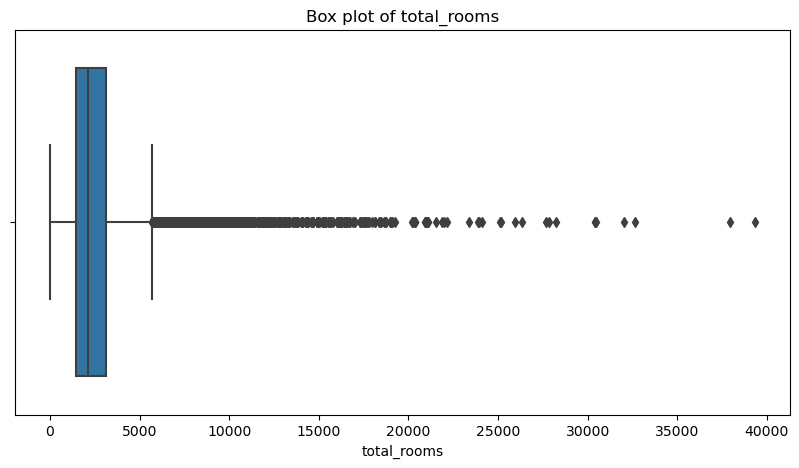

Outliers in total_bedrooms:
95       2477.0
96       1331.0
98       1270.0
100      1414.0
101      1603.0
          ...  
20539    1516.0
20543    1820.0
20544    1857.0
20563    2640.0
20629    1856.0
Name: total_bedrooms, Length: 1306, dtype: float64


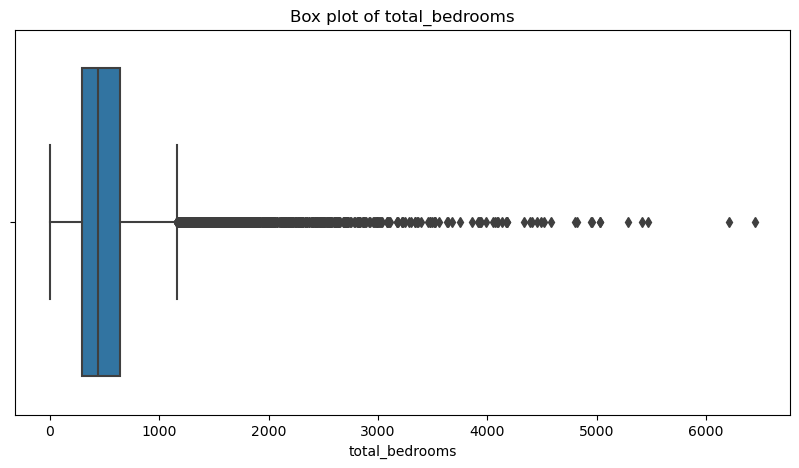

Outliers in population:
95       3469.0
185      4367.0
283      4985.0
460      3337.0
485      3276.0
          ...  
20543    3717.0
20544    6330.0
20563    6837.0
20604    3265.0
20629    6912.0
Name: population, Length: 1196, dtype: float64


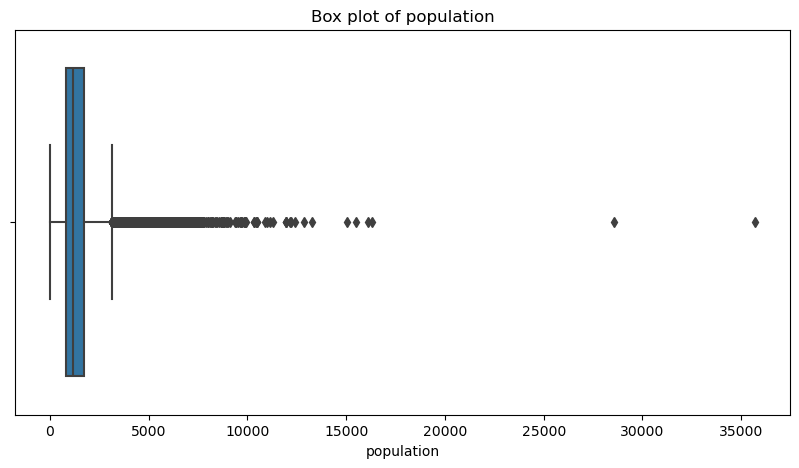

Outliers in households:
1        1138.0
95       2323.0
96       1180.0
98       1250.0
100      1250.0
          ...  
20541    1115.0
20543    1767.0
20544    1832.0
20563    2358.0
20629    1818.0
Name: households, Length: 1220, dtype: float64


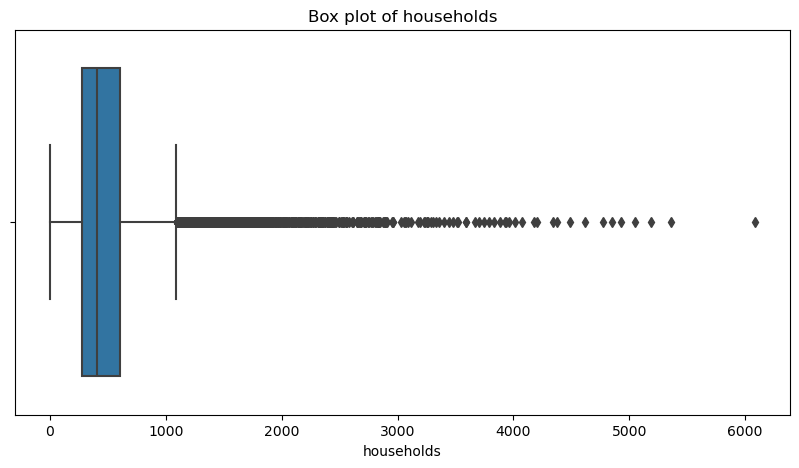

Outliers in median_income:
0         8.3252
1         8.3014
131      11.6017
134       8.2049
135       8.4010
          ...   
20426    10.0472
20427     8.6499
20428     8.7288
20436    12.5420
20503     8.2787
Name: median_income, Length: 681, dtype: float64


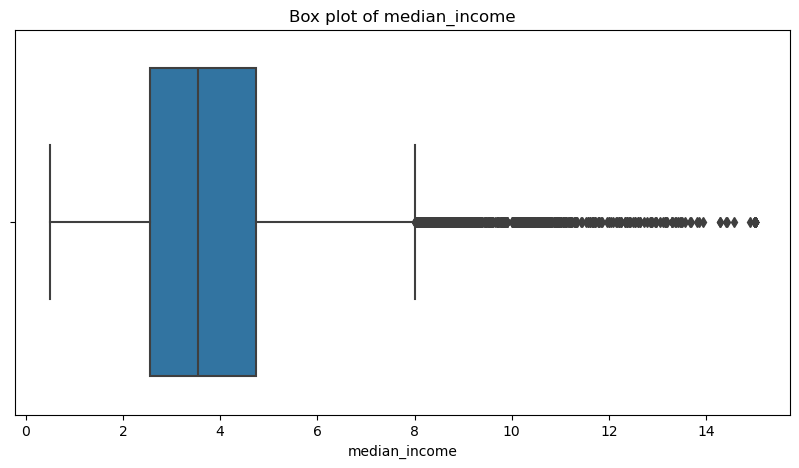

Outliers in median_house_value:
89       500001.0
140      483300.0
459      500001.0
489      489600.0
493      500001.0
           ...   
20422    500001.0
20426    500001.0
20427    500001.0
20436    500001.0
20443    500001.0
Name: median_house_value, Length: 1071, dtype: float64


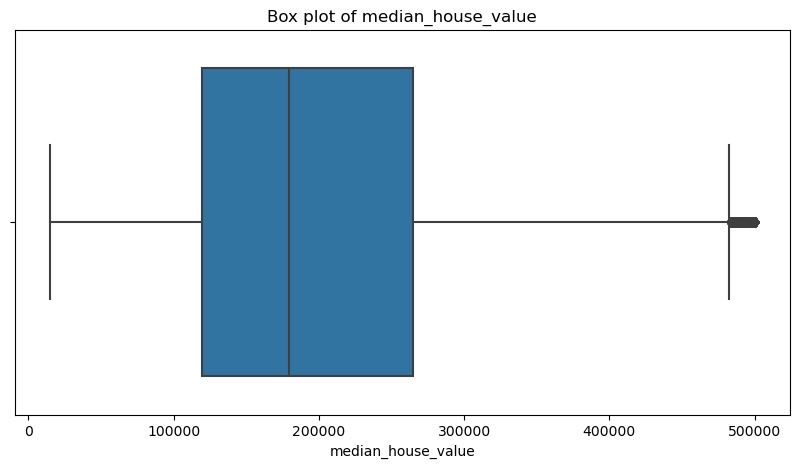

In [47]:
# To identify outlier we can use IQR Method and support that with box plot visualization.
# Numerical variable 


numerical_cols = df.select_dtypes(include=['float'])

# Function to calculate IQR and identify outliers
def identify_outliers(col):
    
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return col[(col < lower_bound) | (col > upper_bound)]

# Detecting outliers for each numerical column and plotting box plots to proof

for col in numerical_cols:
    if col  not in ['longitude','latitude']: # remove columns with binary types
        
        outliers = identify_outliers(df[col])
        print(f"Outliers in {col}:")
        print(outliers)
        
        # Plotting box plot
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=df[col])
        plt.title(f'Box plot of {col}')
        plt.show()

In [56]:
# Identify and Remove Outliers
def remove_outliers(df, col):
    
    Q1 = df[col].quantile(0.20)
    Q3 = df[col].quantile(0.70)
    
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


for col in numerical_cols:
    if col not in ['longitude','latitude']: # remove columns with binary types
        df = remove_outliers(df, col)
        print(f'Removed outliers for columns {col} succefully')


Removed outliers for columns housing_median_age succefully
Removed outliers for columns total_rooms succefully
Removed outliers for columns total_bedrooms succefully
Removed outliers for columns population succefully
Removed outliers for columns households succefully
Removed outliers for columns median_income succefully
Removed outliers for columns median_house_value succefully


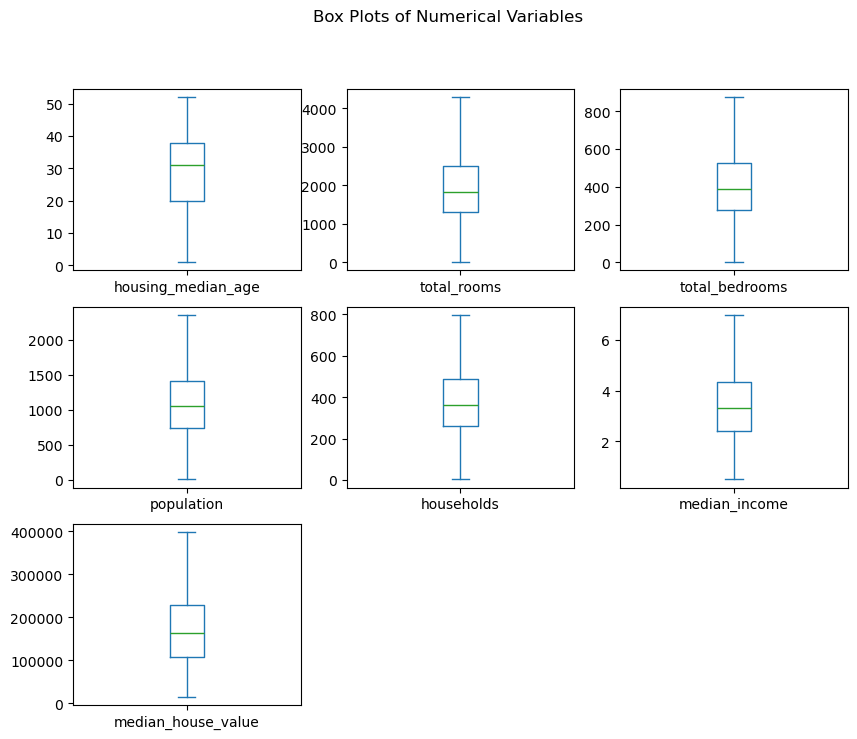

In [61]:
df[['housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value']].plot(kind='box', subplots=True, layout=(3,3), figsize=(10, 8), title='Box Plots of Numerical Variables')
plt.show()

**Data Transformation**

1. Feature creation of construction
2. Scaling / Normalization
3. Feature Encoding



**Feature Creation**

In [64]:
# We have created a new features from existing features

df['rooms_per_households']     = df['total_rooms']  / df['total_bedrooms']
df['population_per_household'] = df['population']  /  df['households']
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_households,population_per_household
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.421277,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,5.810714,2.181467
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,4.314554,2.139896
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY,5.184049,2.128405
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY,4.518195,1.788253


**Data Encoding**

1. Encoding (Data Encoding:)

Encoding is the process of converting data from one form to another, often for the purposes of efficient storage, transmission, or processing. It involves representing information using a specific format or set of rules. 

- In Data Encoding we have 2 approaches

    1. **One Hot Encoding** : 0ne-hot encoding converts categorical variables into a series of binary variables (0 or 1). Each category is represented as a binary vector where only one element is "hot" (1), and the rest are "cold" (0). t’s commonly used when the categorical variable does not have an intrinsic order and is typically used with nominal data.

    2. **Label encoding** assigns each category a unique integer value. Each category is mapped to an integer.It’s often used when the categorical variable has an order or rank (ordinal data). However, it can be misleading when applied to nominal data because the model may incorrectly infer an order or relationship between categories.
    3. **Binary encoding** 
    4. **Frequency encoding**
    5. **Embedding** (In Deep Learning) Converts categories into dense vectors of continuous numbers. These vectors capture relationships between categories in a lower-dimensional space.


In [67]:
# We will use One Hot Encoding function from sklearn model
from sklearn.preprocessing import OneHotEncoder

# Intialize the oneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

#Fit and Transform the data
encoder_data = encoder.fit_transform(df[['ocean_proximity']])
print(encoder_data[0])

#  Convert the encoded data to a DataFrame for easier visualization
encoded_df = pd.DataFrame(encoder_data, columns=encoder.get_feature_names_out(['ocean_proximity']))

df = pd.concat([df, encoded_df], axis=1).drop(columns=['ocean_proximity'])
df.head(1)

[0. 0. 0. 1. 0.]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_households,population_per_household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.421277,2.547945,0.0,0.0,0.0,1.0,0.0


**Feature Scaling**

Its a critical step in data preprocessing for machine learning. It involves adjusting the range and distribution of feature values to ensure that they contribute equally to model training. This is especially important for algorithms that rely on distance measures or assume that features are on similar scales.

Why Feature Scaling?

1. Improve Algorithm Performance

Algorithms like k-Nearest Neighbors (k-NN) and Support Vector Machines (SVM) rely on distance metrics, so features need to be on the same scale to avoid biasing the model.
Gradient Descent-based algorithms, such as Linear Regression and Neural Networks, converge faster and perform better when features are scaled.
Ensure Fairness:

2. Scaling ensures that features with larger ranges do not dominate the learning process

3. Feature scaling can make optimization algorithms converge more quickly.

----
----

**Common Techniques**

1. Min-Max Scaling(Normalization) $$ X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}} $$
2. Standardization (Z-score Normalization) $$X_{scaled} = \frac{X - \mu}{\sigma}$$
3. Robust Scaling  - Uses the median and interquartile range to scale features, making it robust to outliers.$$X_{scaled} = \frac{X - \text{median}}{\text{IQR}}$$
4. Scales features to be within [-1, 1] by dividing by the maximum absolute value.$$X_{scaled} = \frac{X}{\max(|X|)}$$

----
----

**Choosing a Scaling Method**

1. Min-Max Scaling: Use when features need to be within a specific range, especially for algorithms that require normalized data.
2. Standardization: Preferred when features are normally distributed or when algorithms assume data is centered around zero.
3. Robust Scaling: Useful for datasets with significant outliers.
4. MaxAbs Scaling: Effective for data with many zero values or when features are sparse.

In [71]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler


# Print the original DataFrame
print("Original DataFrame:")

# 1. Min-Max Scaling
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df), columns=df.columns)
print("\nMin-Max Scaled Data Done:")

# 2. Standardization
scaler_std = StandardScaler()
df_standardized = pd.DataFrame(scaler_std.fit_transform(df), columns=df.columns)
print("\nStandardized Data Done:")

# 3. MaxAbs Scaling
scaler_maxabs = MaxAbsScaler()
df_maxabs = pd.DataFrame(scaler_maxabs.fit_transform(df), columns=df.columns)
print("\nMaxAbs Scaled Data Done:")

# 4. Robust Scaling
scaler_robust = RobustScaler()
df_robust = pd.DataFrame(scaler_robust.fit_transform(df), columns=df.columns)
print("\nRobust Scaled Data Done:")


Original DataFrame:

Min-Max Scaled Data Done:

Standardized Data Done:

MaxAbs Scaled Data Done:

Robust Scaled Data Done:


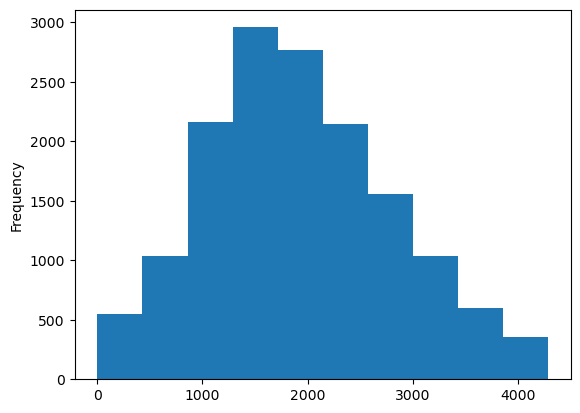

In [87]:
df['total_rooms'].plot(kind='hist');  # histogram of total_rooms

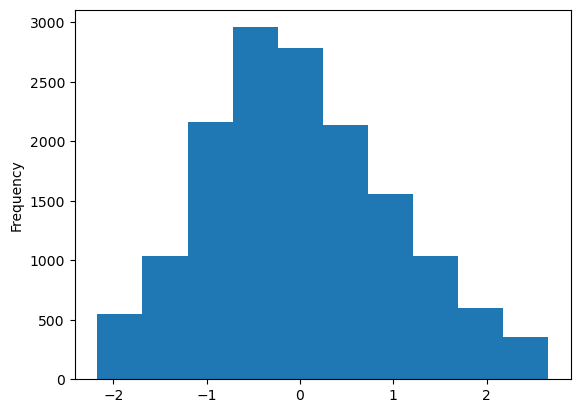

In [90]:
df_standardized['total_rooms'].plot(kind='hist'); # Histogram of scaled total rooms

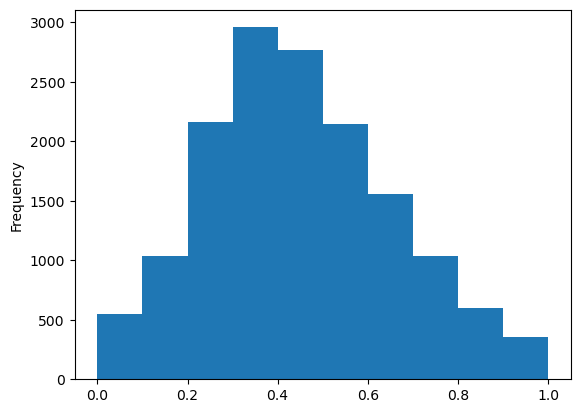

In [91]:
df_minmax['total_rooms'].plot(kind='hist'); # Histogram of scaled total rooms using minmax